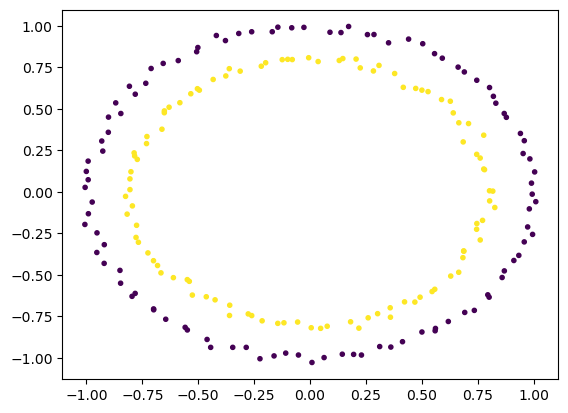

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.datasets import make_circles
# Generate dataset and targets
X, Y = make_circles(n_samples = 200, noise = 0.02)
 
# visualizing data
plt.scatter(X[:, 0], X[:, 1], c = Y, marker = '.')
plt.show()

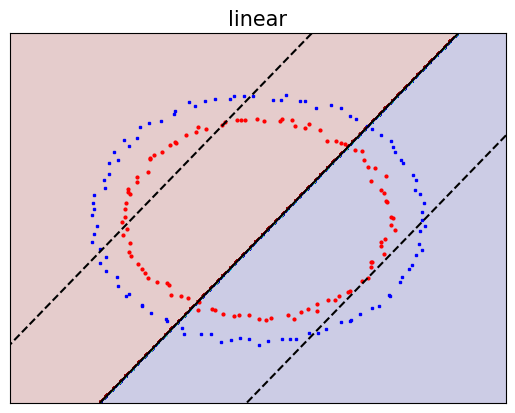

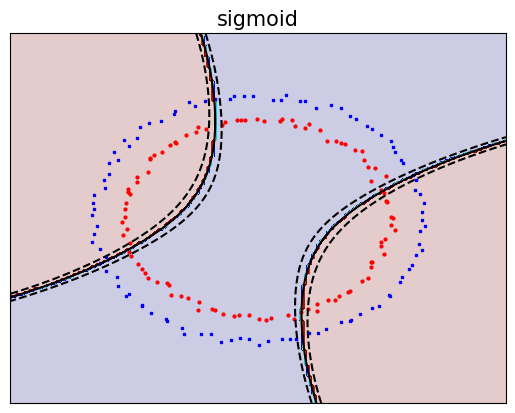

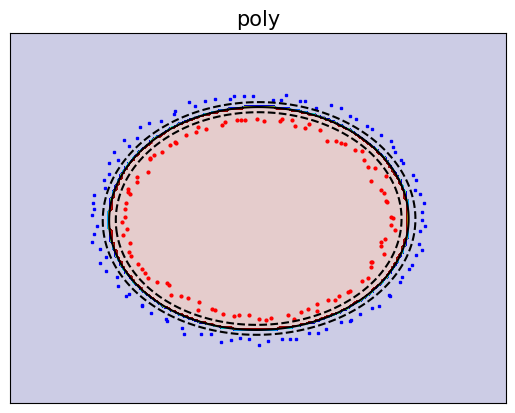

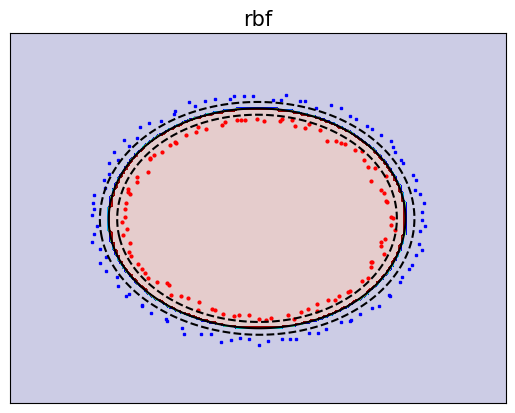

In [6]:
fignum = 1
# fit the model
for kernel in ('linear','sigmoid', 'poly', 'rbf'):
    clf = svm.SVC(kernel=kernel, gamma=1, coef0 = 1)
    clf.fit(X, Y)
    with PdfPages(kernel + '3.pdf') as pdf:
    # plot the line, the points, and the nearest vectors to the plane
        fig, ax = plt.subplots()
        plt.figure(fignum, figsize=(5, 5))
        plt.clf()
        plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80, facecolors='None')
        plt.plot(X[Y==0, 0], X[Y==0, 1], 'bs', markersize = 2)
        plt.plot(X[Y==1, 0], X[Y==1, 1], 'ro', markersize = 2)
        plt.axis('tight')
        x_min = -1.5
        x_max = 1.5
        y_min = -1.5
        y_max = 1.5
        XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
        Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
        # Put the result into a color plot
        Z = Z.reshape(XX.shape)
        plt.figure(fignum, figsize=(5, 5))
        CS = plt.contourf(XX, YY, np.sign(Z), 200, cmap='jet', alpha = .2)
        plt.contour(XX, YY, Z, colors=['k', 'k', 'k'], linestyles=['--', '-', '--'],
        levels=[-.5, 0, .5])
        plt.title(kernel, fontsize = 15)
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.xticks(())
        plt.yticks(())
        fignum = fignum + 1
        pdf.savefig()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
Y = np.array([-1 if a < 1 else 1 for a in Y])
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3,random_state=109)

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
clf = SVC(kernel = 'linear', C = 100) # use the same C
# if C is small, method will be “SoftMagin SVM”, 
# if C is large enough, method is near to hard margin
clf.fit(X_train, y_train) 

w = clf.coef_
w0 = clf.intercept_
y_pred = clf.predict(X_test)
print('Accuracy =', accuracy_score(y_pred,y_test))
print('w = ', w)
print('b = ', w0)

Accuracy = 0.3333333333333333
w =  [[-9.12025864e-05 -2.04277319e-04]]
b =  [0.99997353]


Ex2:

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
dataset = pd.read_csv('D:\\Code\\Python\\MachineLearning\\Week_11\\dataset.csv')
X = dataset.iloc[:, :-1].values
Y = dataset.iloc[:, -1].values
from sklearn.model_selection import train_test_split
XTrain, XTest, yTrain, yTest = train_test_split(X, Y, test_size = 0.25, random_state = 0)
# Chuyển vị ma trận dữ liệu do ta đọc bằng Pandas => mỗi record là 1 dong
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
XTrain = sc.fit_transform(XTrain)
XTest = sc.transform(XTest)
fignum = 1
# fit the model
for kernel in ('linear','sigmoid', 'poly', 'rbf'):
    clf = svm.SVC(kernel=kernel, gamma=1, coef0 = 1)
    clf.fit(X, Y)
    with PdfPages(kernel + '3.pdf') as pdf:
    # plot the line, the points, and the nearest vectors to the plane
        fig, ax = plt.subplots()
        plt.figure(fignum, figsize=(5, 5))
        plt.clf()
        plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80, facecolors='None')
        plt.plot(X[Y==0, 0], X[Y==0, 1], 'bs', markersize = 2)
        plt.plot(X[Y==1, 0], X[Y==1, 1], 'ro', markersize = 2)
        plt.axis('tight')
        x_min = -1.5
        x_max = 1.5
        y_min = -1.5
        y_max = 1.5
        XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
        Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
        # Put the result into a color plot
        Z = Z.reshape(XX.shape)
        plt.figure(fignum, figsize=(5, 5))
        CS = plt.contourf(XX, YY, np.sign(Z), 200, cmap='jet', alpha = .2)
        plt.contour(XX, YY, Z, colors=['k', 'k', 'k'], linestyles=['--', '-', '--'],
        levels=[-.5, 0, .5])
        plt.title(kernel, fontsize = 15)
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.xticks(())
        plt.yticks(())
        fignum = fignum + 1
        pdf.savefig()
plt.show()

Bai tap thuc hanh 1:

In [2]:
import scipy.io as sio
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load data
A = sio.loadmat('D:\Code\Python\MachineLearning\Week_11\ARgender.mat')
X_train = A['Y_train'].T
X_test = A['Y_test'].T
N = 700
y_train = A['label_train'].reshape(N)
y_test = A['label_test'].reshape(N)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train and predict with SVM model using different kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svm_model = SVC(kernel=kernel)
    svm_model.fit(X_train, y_train)
    y_pred_train = svm_model.predict(X_train)
    y_pred_test = svm_model.predict(X_test)
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    print("Kernel: {}, Training accuracy: {:.2f}%, Test accuracy: {:.2f}%".format(kernel, train_acc*100, test_acc*100))

Kernel: linear, Training accuracy: 100.00%, Test accuracy: 88.29%
Kernel: poly, Training accuracy: 94.00%, Test accuracy: 50.71%
Kernel: rbf, Training accuracy: 100.00%, Test accuracy: 88.57%
Kernel: sigmoid, Training accuracy: 98.86%, Test accuracy: 83.86%


Bai tap thuc hanh 2:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Load data
dataset = pd.read_csv('D:\Code\Python\MachineLearning\Week_11\dataset.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Split data into training and test sets
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Scale the data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
XTrain = sc.fit_transform(XTrain)
XTest = sc.transform(XTest)

# Train the logistic regression model
classifier = LogisticRegression(random_state = 0)
classifier.fit(XTrain, yTrain)

# Predict the test set results and calculate evaluation metrics
yPred = classifier.predict(XTest)
cm = confusion_matrix(yTest, yPred)
accuracy = accuracy_score(yTest, yPred)
precision = precision_score(yTest, yPred)
recall = recall_score(yTest, yPred)
f1 = f1_score(yTest, yPred)

# Print the evaluation metrics
print("Confusion matrix:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Confusion matrix:
 [[65  3]
 [ 8 24]]
Accuracy: 0.89
Precision: 0.8888888888888888
Recall: 0.75
F1-score: 0.8135593220338982


Bai tap thuc hanh 3:

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm_models = []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    svm_models.append(svm)

for i, svm in enumerate(svm_models):
    y_pred = svm.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy with kernel {}: {:.2f}%".format(kernels[i], acc*100))

Accuracy with kernel linear: 95.61%
Accuracy with kernel poly: 94.74%
Accuracy with kernel rbf: 94.74%
Accuracy with kernel sigmoid: 46.49%
